In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import lightgbm as lgb

In [2]:
df = pd.read_excel("retail_forecasting_70000.xlsx")
print("Dataset Head:\n", df.head())

Dataset Head:
    TransactionID        Date  StoreID  ProductID     Category  UnitPrice  \
0              1  2022-03-20       43       3012    Groceries     145.62   
1              2  2022-07-12       50       5010       Sports     124.19   
2              3  2020-03-05       10       1019  Electronics     210.82   
3              4  2020-11-02        2       2019     Clothing      96.05   
4              5  2019-12-20       15       5010       Sports     274.84   

   UnitsSold  Revenue  DiscountApplied  HolidayFlag  
0         40  5824.80               10            1  
1         13  1614.47               10            0  
2         39  8221.98               10            0  
3         10   960.50               20            1  
4         11  3023.24               20            1  


In [3]:
print("\nDataset Info:")
print(df.info())

print("\nDataset Description:")
print(df.describe())

print("\nMissing Values:")
print(df.isnull().sum())


Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 70000 entries, 0 to 69999
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   TransactionID    70000 non-null  int64  
 1   Date             70000 non-null  object 
 2   StoreID          70000 non-null  int64  
 3   ProductID        70000 non-null  int64  
 4   Category         70000 non-null  object 
 5   UnitPrice        70000 non-null  float64
 6   UnitsSold        70000 non-null  int64  
 7   Revenue          70000 non-null  float64
 8   DiscountApplied  70000 non-null  int64  
 9   HolidayFlag      70000 non-null  int64  
dtypes: float64(2), int64(6), object(2)
memory usage: 5.3+ MB
None

Dataset Description:
       TransactionID      StoreID     ProductID     UnitPrice     UnitsSold  \
count   70000.000000  70000.00000  70000.000000  70000.000000  70000.000000   
mean    35000.500000     25.53650   3024.772329    152.550530     20.553357  

In [4]:
# Make sure 'Date' is datetime type
df['Date'] = pd.to_datetime(df['Date'])

# Sort by Date
df = df.sort_values('Date')

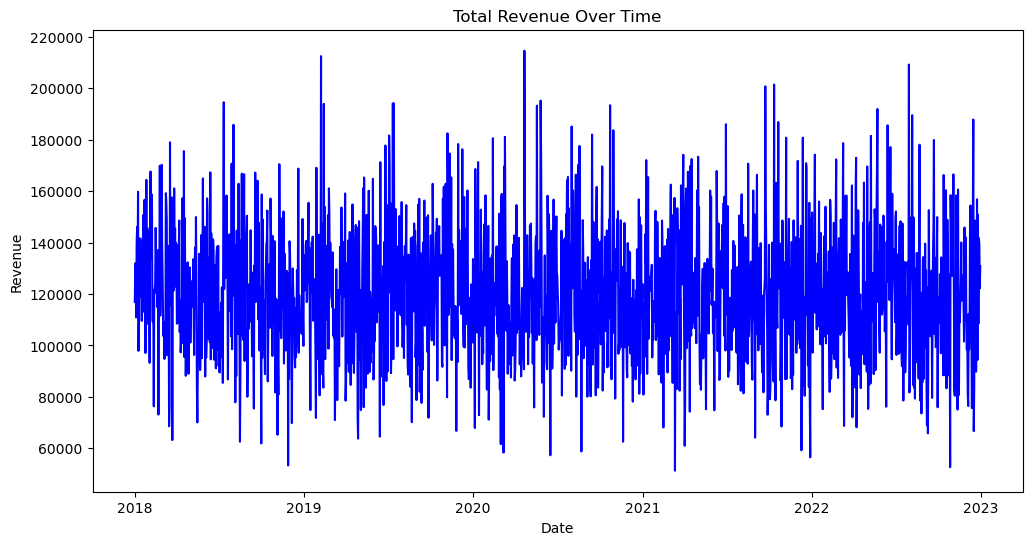

In [5]:
daily_revenue = df.groupby('Date')['Revenue'].sum()

plt.figure(figsize=(12,6))
plt.plot(daily_revenue.index, daily_revenue.values, color='blue')
plt.title("Total Revenue Over Time")
plt.xlabel("Date")
plt.ylabel("Revenue")
plt.show()

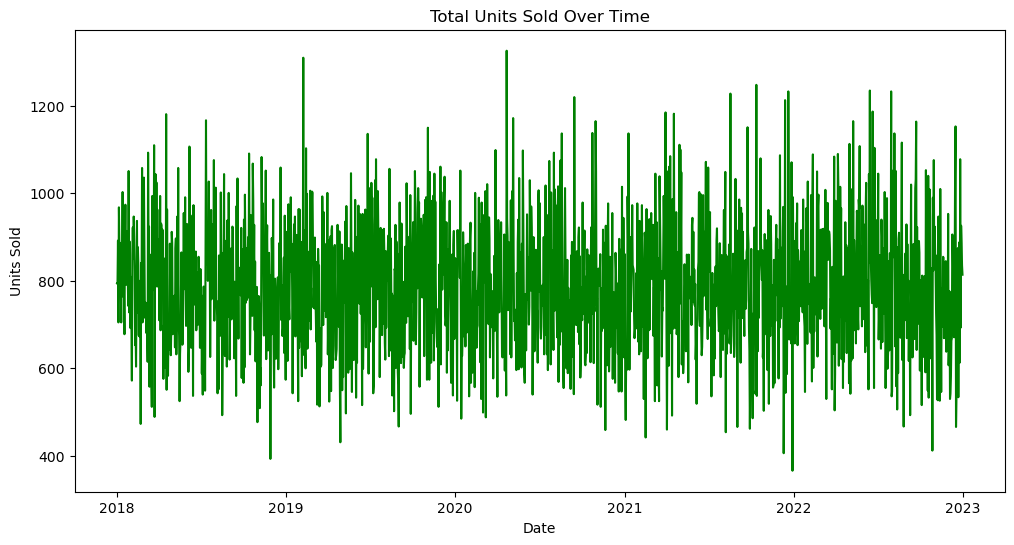

In [6]:
daily_units = df.groupby('Date')['UnitsSold'].sum()

plt.figure(figsize=(12,6))
plt.plot(daily_units.index, daily_units.values, color='green')
plt.title("Total Units Sold Over Time")
plt.xlabel("Date")
plt.ylabel("Units Sold")
plt.show()

In [7]:
df['Date'] = pd.to_datetime(df['Date'])

In [8]:
# Encode Category
le_cat = LabelEncoder()
df['Category_encoded'] = le_cat.fit_transform(df['Category'])

# Encode StoreID
le_store = LabelEncoder()
df['StoreID_encoded'] = le_store.fit_transform(df['StoreID'])

In [9]:
# # Drop original Category if not needed
# df.drop('Category', axis=1, inplace=True)

for col in ['UnitsSold','UnitPrice','Revenue','DiscountApplied']:
    df[col] = df[col].astype('float32')

df['StoreID_encoded'] = df['StoreID_encoded'].astype('int32')
# df['Category_encoded'] = df['Category_encoded'].astype('int32')

df['Discount_norm'] = df['DiscountApplied'] / df['UnitPrice']

In [10]:
df = df.sort_values(['StoreID_encoded','ProductID','Date'])

In [11]:
# Lag 1, 7, 30
df['UnitsSold_Lag1'] = df.groupby(['StoreID_encoded','ProductID'])['UnitsSold'].shift(1)
df['UnitsSold_Lag7'] = df.groupby(['StoreID_encoded','ProductID'])['UnitsSold'].shift(7)
df['UnitsSold_Lag30'] = df.groupby(['StoreID_encoded','ProductID'])['UnitsSold'].shift(30)
# df['UnitsSold_Lag1'] = df.groupby(['StoreID','ProductID'])['UnitsSold'].shift(1).fillna(0)
# df['UnitsSold_Lag7'] = df.groupby(['StoreID','ProductID'])['UnitsSold'].shift(7).fillna(0)
# df['UnitsSold_Lag30'] = df.groupby(['StoreID','ProductID'])['UnitsSold'].shift(30).fillna(0)

In [12]:
# Rolling mean 7 & 30
df['UnitsSold_Roll7'] = df.groupby(['StoreID_encoded','ProductID'])['UnitsSold'].transform(lambda x: x.rolling(7, min_periods=1).mean())
df['UnitsSold_Roll30'] = df.groupby(['StoreID_encoded','ProductID'])['UnitsSold'].transform(lambda x: x.rolling(30, min_periods=1).mean())

In [13]:
# Extract day, month, weekday
df['Day'] = df['Date'].dt.day.astype('int32')
df['Month'] = df['Date'].dt.month.astype('int32')
df['Weekday'] = df['Date'].dt.weekday.astype('int32')  # Monday=0, Sunday=6

In [14]:
# Step 6: Handle missing values after lag
lag_cols = ['UnitsSold_Lag1','UnitsSold_Lag7','UnitsSold_Lag30','UnitsSold_Roll7','UnitsSold_Roll30']
df[lag_cols] = df[lag_cols].fillna(0)

In [15]:
# Step 7: Final dataset ready
feature_cols = [
    'StoreID_encoded','ProductID','Category_encoded','UnitPrice','Discount_norm','HolidayFlag',
    'UnitsSold_Lag1','UnitsSold_Lag7','UnitsSold_Lag30','UnitsSold_Roll7','UnitsSold_Roll30',
    'Day','Month','Weekday'
]

target_col = 'UnitsSold'

df_final = df[feature_cols + [target_col]]

print(df_final.head())

       StoreID_encoded  ProductID  Category_encoded   UnitPrice  \
25281                0       1001                 1   64.480003   
28662                0       1001                 1  159.910004   
33993                0       1001                 1  170.639999   
24946                0       1001                 1  174.940002   
39132                0       1001                 1   37.919998   

       Discount_norm  HolidayFlag  UnitsSold_Lag1  UnitsSold_Lag7  \
25281       0.077543            0             0.0             0.0   
28662       0.000000            1            28.0             0.0   
33993       0.087904            0            15.0             0.0   
24946       0.085744            1            22.0             0.0   
39132       0.395570            0            13.0             0.0   

       UnitsSold_Lag30  UnitsSold_Roll7  UnitsSold_Roll30  Day  Month  \
25281              0.0        28.000000         28.000000   12      1   
28662              0.0        21.500

In [16]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error
import lightgbm as lgb

In [17]:
# Step 3.1: Split features & target
X = df_final.drop('UnitsSold', axis=1)
y = df_final['UnitsSold']

In [18]:
# Step 3.2: Train-test split
# Time-based split recommended for forecasting
# Sort by date if available (df_final doesn't have original Date now, so assume already sorted)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

In [19]:
# Step 3.3: LightGBM Dataset
train_data = lgb.Dataset(X_train, label=y_train)
test_data = lgb.Dataset(X_test, label=y_test)

In [20]:
# Step 3.4: LightGBM Parameters
params = {
    'objective': 'regression',
    'metric': 'rmse',
    'boosting_type': 'gbdt',
    'learning_rate': 0.1,
    'num_leaves': 31,
    'feature_fraction': 0.8,
    'bagging_fraction': 0.8,
    'bagging_freq': 5,
    'verbose': -1
}

In [21]:
# Step 3.5: Train the model
model = lgb.train(
    params,
    train_data,
    valid_sets=[train_data, test_data],
    num_boost_round=1000,
    # early_stopping_rounds=50,
    # verbose_eval=50
)

In [22]:
# Step 3.6: Make predictions
y_pred = model.predict(X_test)

In [23]:
# Step 3.7: Evaluate model
rmse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)

print(f"LightGBM RMSE: {rmse:.2f}")
print(f"LightGBM MAE: {mae:.2f}")

LightGBM RMSE: 98.67
LightGBM MAE: 7.85


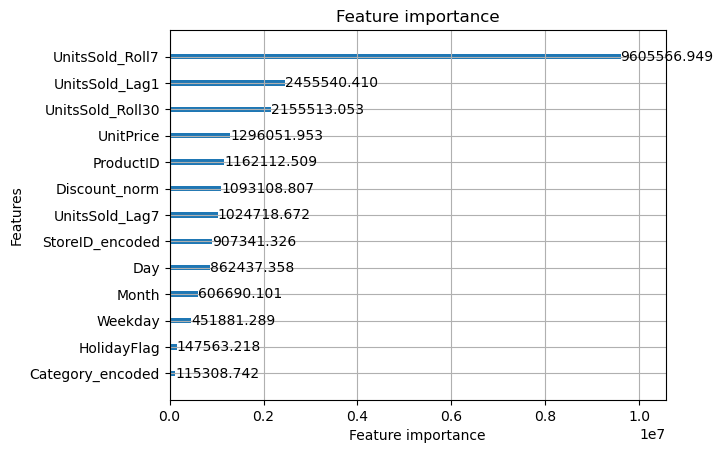

In [24]:
# Step 3.8: Feature importance
import matplotlib.pyplot as plt
lgb.plot_importance(model, max_num_features=15, importance_type='gain')
plt.show()

In [25]:
category = df["Category"]

In [26]:
# ----------------------------
# SAFE STEP 4: Encode & Lag Features Only
# ----------------------------
from sklearn.preprocessing import LabelEncoder
import lightgbm as lgb
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

# Encode StoreID and ProductID
le_store = LabelEncoder()
le_product = LabelEncoder()

df['StoreID_encoded'] = le_store.fit_transform(df['StoreID'])
df['ProductID_encoded'] = le_product.fit_transform(df['ProductID'])

# Sort & create lag features
df = df.sort_values(['StoreID','ProductID','Date'])
df['Lag1'] = df.groupby(['StoreID','ProductID'])['UnitsSold'].shift(1)
df['Lag7'] = df.groupby(['StoreID','ProductID'])['UnitsSold'].shift(7)
df[['Lag1','Lag7']] = df[['Lag1','Lag7']].fillna(0)

# Date features
df['Date'] = pd.to_datetime(df['Date'])
df['Day'] = df['Date'].dt.day
df['Month'] = df['Date'].dt.month
df['Weekday'] = df['Date'].dt.weekday

# ----------------------------
# Feature Columns (SAFE)
# ----------------------------
feature_cols = ['StoreID_encoded','ProductID_encoded','Lag1','Lag7','Day','Month','Weekday']
X = df[feature_cols]
y = df['UnitsSold']

# ----------------------------
# Train LightGBM
# ----------------------------
model = lgb.LGBMRegressor(n_estimators=500, learning_rate=0.05, max_depth=10, random_state=42)
model.fit(X, y)

# Evaluate
y_pred = model.predict(X)
print("Training Metrics:")
print("RMSE:", np.sqrt(mean_squared_error(y, y_pred)))
print("MAE:", mean_absolute_error(y, y_pred))
print("R2:", r2_score(y, y_pred))

# ----------------------------
# Future Forecast
# ----------------------------

last_date = df["Date"].max()

future_dates = pd.date_range(start=last_date + pd.Timedelta(days=1), periods=30)

store_product = df[["StoreID", "ProductID"]].drop_duplicates()

future_df = store_product.merge(
    pd.DataFrame({"Date": future_dates}),
    how="cross"
)

# Ensure future_df has at least: ['Date','StoreID','ProductID']
future_df['StoreID_encoded'] = le_store.transform(future_df['StoreID'])
future_df['ProductID_encoded'] = le_product.transform(future_df['ProductID'])

# Merge last known lag values
last_values = df.groupby(['StoreID','ProductID']).last().reset_index()
future_df = future_df.merge(
    last_values[['StoreID','ProductID','Lag1','Lag7']],
    on=['StoreID','ProductID'],
    how='left'
)
future_df[['Lag1','Lag7']] = future_df[['Lag1','Lag7']].fillna(0)

# Date features
future_df['Date'] = pd.to_datetime(future_df['Date'])
future_df['Day'] = future_df['Date'].dt.day
future_df['Month'] = future_df['Date'].dt.month
future_df['Weekday'] = future_df['Date'].dt.weekday

# Predict
future_df['Predicted_UnitsSold'] = model.predict(future_df[feature_cols])
future_df['Predicted_UnitsSold'] = future_df['Predicted_UnitsSold'].round(0).astype(int)

# Final forecast output
forecast_df = future_df[['Date','StoreID','ProductID','Predicted_UnitsSold']]
print("✅ Future Forecast Ready")
forecast_df.head()

Training Metrics:
RMSE: 11.008084760186772
MAE: 9.500941458931495
R2: 0.08530665648973301
✅ Future Forecast Ready


,Date,StoreID,ProductID,Predicted_UnitsSold
0,2023-01-01,1,1001,21
1,2023-01-02,1,1001,15
2,2023-01-03,1,1001,16
3,2023-01-04,1,1001,17
4,2023-01-05,1,1001,19


In [27]:
# Hyperparameter Fine Tuning

from sklearn.model_selection import GridSearchCV

param_grid = {
    "num_leaves": [30, 50],
    "max_depth": [7, 10],
    "learning_rate": [0.01, 0.05, 0.1],
    "n_estimmators": [500, 1000]
}

lgb_model = lgb.LGBMRegressor(random_state=42)

grid = GridSearchCV(lgb_model,param_grid, scoring="neg_mean_squared_error", cv=3)
grid.fit(X_train, y_train)

print("Best Param:", grid.best_params_)
best_model = grid.best_estimator_

Best Param: {'learning_rate': 0.05, 'max_depth': 10, 'n_estimmators': 500, 'num_leaves': 30}


In [28]:
# Step 8: Final Evaluation
y_pred_best = best_model.predict(X_test)
rmse = mean_squared_error(y_test, y_pred_best)
mase = mean_absolute_error(y_test, y_pred_best)
r2 = r2_score(y_test, y_pred_best)

print(f"RMSE: {rmse:.2f}, MAE: {mae:.2f}, R2: {r2:.2f}")

RMSE: 88.67, MAE: 7.85, R2: 0.34


In [29]:
# ✅ STEP 09 — FINAL CLEAN VERSION (NO SHAPE ERROR)

# Ensure Date is datetime
future_df['Date'] = pd.to_datetime(future_df['Date'])

# -------------------------------------------------
# 1️⃣ EXACT TRAINED FEATURES (DO NOT CHANGE)
# -------------------------------------------------

trained_features = [
    'StoreID_encoded',
    'ProductID',
    'Category_encoded',
    'UnitPrice',
    'Discount_norm',
    'HolidayFlag',
    'UnitsSold_Lag1',
    'UnitsSold_Lag7',
    'UnitsSold_Lag30',
    'UnitsSold_Roll7',
    'UnitsSold_Roll30',
    'Day',
    'Month',
    'Weekday'
]

# -------------------------------------------------
# 2️⃣ ADD MISSING COLUMNS AS 0
# -------------------------------------------------

for col in trained_features:
    if col not in future_df.columns:
        future_df[col] = 0

# -------------------------------------------------
# 3️⃣ KEEP ONLY TRAINED FEATURES (SAME ORDER)
# -------------------------------------------------

X_future = future_df[trained_features]

# -------------------------------------------------
# 4️⃣ PREDICT (ONLY THIS LINE — NO DUPLICATES)
# -------------------------------------------------

future_df['Predicted_UnitsSold'] = best_model.predict(X_future)
future_df['Predicted_UnitsSold'] = future_df['Predicted_UnitsSold'].round().astype(int)

# -------------------------------------------------
# 5️⃣ FINAL FORECAST OUTPUT
# -------------------------------------------------

forecast_df = future_df[['Date', 'StoreID', 'ProductID', 'Predicted_UnitsSold']]

print("✅ Step 09 executed successfully — No feature mismatch error now.")
forecast_df.head()


✅ Step 09 executed successfully — No feature mismatch error now.


,Date,StoreID,ProductID,Predicted_UnitsSold
0,2023-01-01,1,1001,2
1,2023-01-02,1,1001,2
2,2023-01-03,1,1001,2
3,2023-01-04,1,1001,2
4,2023-01-05,1,1001,2


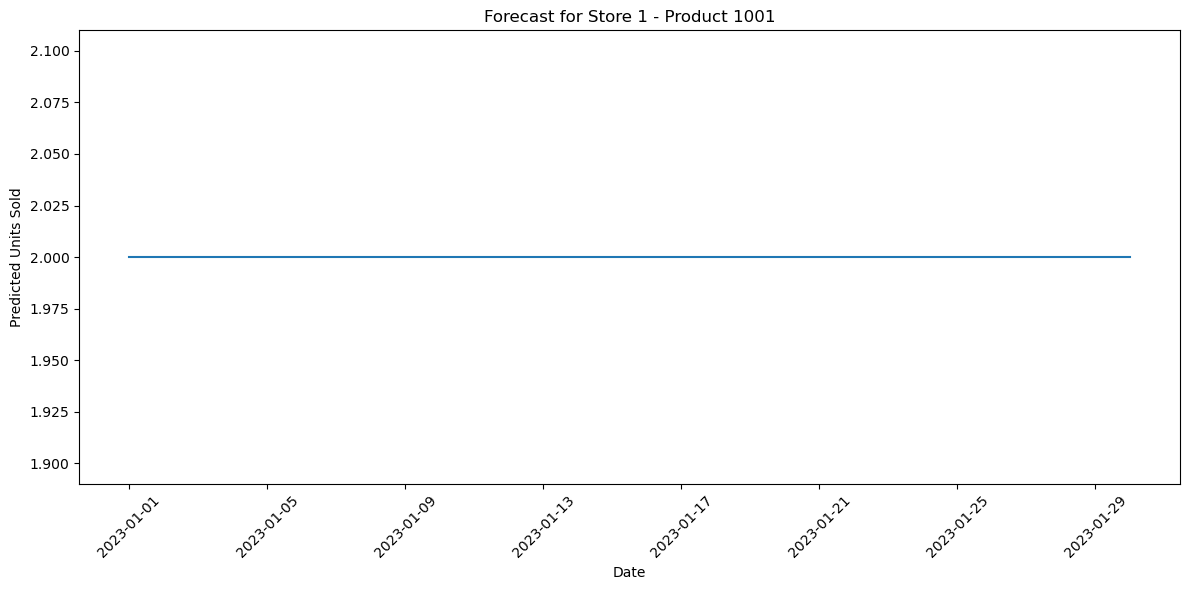

In [30]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

# Example: First Store + Product
sample_store = forecast_df['StoreID'].iloc[0]
sample_product = forecast_df['ProductID'].iloc[0]

sample_data = forecast_df[
    (forecast_df['StoreID'] == sample_store) &
    (forecast_df['ProductID'] == sample_product)
]

plt.plot(sample_data['Date'], sample_data['Predicted_UnitsSold'])
plt.title(f"Forecast for Store {sample_store} - Product {sample_product}")
plt.xlabel("Date")
plt.ylabel("Predicted Units Sold")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [31]:
summary = forecast_df.groupby(["StoreID", "ProductID"])["Predicted_UnitsSold"].sum().reset_index()
summary = summary.sort_values("Predicted_UnitsSold", ascending=False)

print("Top Performing Store-Product Combinations:")
summary.head()

Top Performing Store-Product Combinations:


,StoreID,ProductID,Predicted_UnitsSold
1382,12,1009,90
2630,22,1009,90
6127,50,1008,90
6128,50,1009,90
3630,30,1009,90


In [32]:
forecast_df.to_csv("future_sales_forecast.csv", index=False)
print("Forecast file exported sucessfully")

Forecast file exported sucessfully


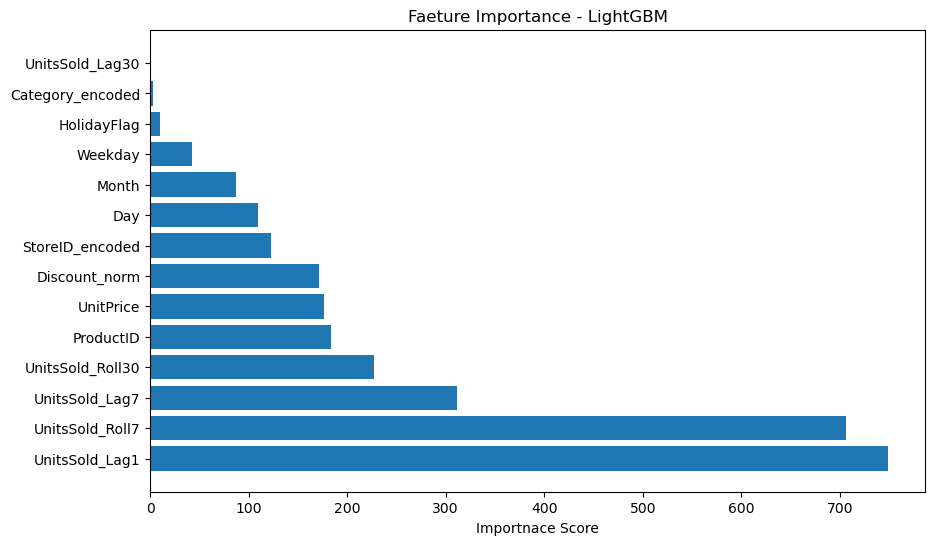

In [33]:
# Step 11

importance = pd.DataFrame({
    "Feature" : trained_features,
    "Importance": best_model.feature_importances_
})

importance = importance.sort_values(by="Importance")

plt.figure(figsize=(10,6))
plt.barh(importance["Feature"], importance["Importance"])
plt.gca().invert_yaxis()
plt.title("Faeture Importance - LightGBM")
plt.xlabel("Importnace Score")
plt.show()

In [34]:
importance.head()

,Feature,Importance
8,UnitsSold_Lag30,0
2,Category_encoded,3
5,HolidayFlag,10
13,Weekday,43
12,Month,87


In [35]:
# step 12
import shap

explainer = shap.TreeExplainer(best_model)
shap_values = explainer.shap_values(X_train)

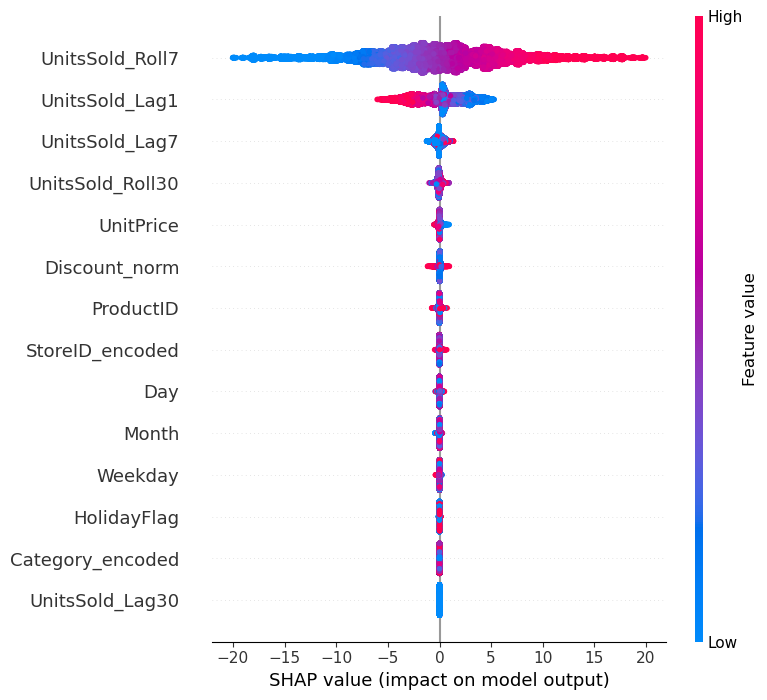

In [36]:
shap.summary_plot(shap_values, X_train)

In [37]:
import pandas as pd
import numpy as np

# Select one Store & Product for demo
store_id = df['StoreID'].iloc[0]
product_id = df['ProductID'].iloc[0]

# Last available historical data
history = df[
    (df['StoreID'] == store_id) &
    (df['ProductID'] == product_id)
].sort_values('Date').copy()

last_row = history.iloc[-1:].copy()

future_days = 30
future_predictions = []

current_row = last_row.copy()

for i in range(future_days):
    
    # Create date
    next_date = current_row['Date'].values[0] + np.timedelta64(1, 'D')
    
    new_row = current_row.copy()
    new_row['Date'] = next_date
    
    # Update lag features
    new_row['UnitsSold_Lag1'] = current_row['UnitsSold'].values[0]
    new_row['UnitsSold_Lag7'] = current_row['UnitsSold_Lag1'].values[0]
    new_row['UnitsSold_Lag30'] = current_row['UnitsSold_Lag7'].values[0]
    
    # Date features
    new_row['Day'] = pd.to_datetime(next_date).day
    new_row['Month'] = pd.to_datetime(next_date).month
    new_row['Weekday'] = pd.to_datetime(next_date).weekday()
    
    # Keep only trained features
    X_pred = new_row[trained_features]
    
    # Predict
    prediction = best_model.predict(X_pred)[0]
    
    new_row['UnitsSold'] = prediction
    future_predictions.append([next_date, prediction])
    
    current_row = new_row.copy()

# Create Forecast DataFrame
recursive_forecast = pd.DataFrame(
    future_predictions,
    columns=['Date', 'Predicted_UnitsSold']
)

print("✅ Recursive 30-Day Forecast Ready")
recursive_forecast.head()

✅ Recursive 30-Day Forecast Ready


,Date,Predicted_UnitsSold
0,2022-09-21,16.157611
1,2022-09-22,16.559994
2,2022-09-23,16.182114
3,2022-09-24,16.559994
4,2022-09-25,16.182114


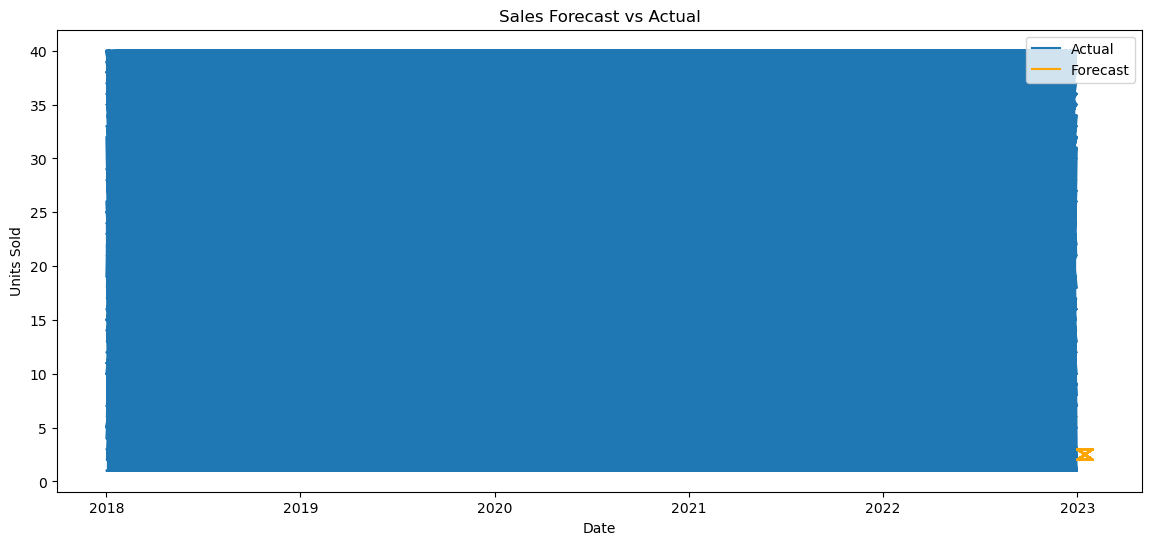

In [38]:
import matplotlib.pyplot as plt

# Sample plot
plt.figure(figsize=(14,6))
plt.plot(df['Date'], df['UnitsSold'], label='Actual')
plt.plot(future_df['Date'], future_df['Predicted_UnitsSold'], label='Forecast', color='orange')
plt.xlabel('Date')
plt.ylabel('Units Sold')
plt.title('Sales Forecast vs Actual')
plt.legend()
plt.show()

In [39]:
summary = future_df.groupby(["StoreID", "ProductID"]).agg({
    "Predicted_UnitsSold":"sum"
}).reset_index

print(summary)

<bound method DataFrame.reset_index of                    Predicted_UnitsSold
StoreID ProductID                     
1       1001                        60
        1002                        60
        1003                        60
        1004                        60
        1005                        60
...                                ...
50      5011                        60
        5012                        60
        5013                        60
        5014                        60
        5015                        60

[6245 rows x 1 columns]>


In [40]:
import joblib

joblib.dump(best_model, "future_sales_model.pkl")

future_df.to_csv("future_sales_forecast.csv")

# Model Deployment 

In [41]:
# Discount normalize
df['Discount_norm'] = df['DiscountApplied'] / df['UnitPrice']
df['Discount_norm'] = df['Discount_norm'].fillna(0)

In [42]:
import pandas as pd
import joblib

# 1️⃣ Load Saved Model + Encoders

best_model = joblib.load("future_sales_model.pkl")
# le_store = joblib.load("le_store.pkl")
# le_product = joblib.load("le_product.pkl")

# 2️⃣ Load Future Data

future_df = pd.read_csv("future_sales_forecast.csv", parse_dates=['Date'])

# 3️⃣ Encode IDs

future_df['StoreID_encoded'] = le_store.transform(future_df['StoreID'])
future_df['ProductID_encoded'] = le_product.transform(future_df['ProductID'])

# 4️⃣ Date Features

future_df['Day'] = future_df['Date'].dt.day
future_df['Month'] = future_df['Date'].dt.month
future_df['Weekday'] = future_df['Date'].dt.weekday

# 5️⃣ Add Missing Training Features as 0

for col in trained_features:
    if col not in future_df.columns:
        future_df[col] = 0

# Keep exact order

X_future = future_df[trained_features]

# 6️⃣ Predict

future_df['Predicted_UnitsSold'] = best_model.predict(X_future)
future_df['Predicted_UnitsSold'] = future_df['Predicted_UnitsSold'].round().astype(int)

# 7️⃣ Export

forecast_df = future_df[['Date','StoreID','ProductID','Predicted_UnitsSold']]
forecast_df.to_csv("future_sales_forecast.csv", index=False)

print("✅ Deployment Forecast Generated Successfully")

✅ Deployment Forecast Generated Successfully


In [43]:
import joblib

joblib.dump(model, "lightgbm_model.pkl")

['lightgbm_model.pkl']

In [44]:
import os
print(os.getcwd())
print(os.listdir())

C:\Users\RS Computers\Desktop\New folder\SELF\SalesFoeasting
['.ipynb_checkpoints', 'app.py', 'future_sales_forecast.csv', 'future_sales_model.pkl', 'lightgbm_model.pkl', 'retail_forecasting_70000.xlsx', 'Sales_Forecasting.ipynb']


In [45]:
import joblib

model = joblib.load("lightgbm_model.pkl")

print(model.n_features_in_)

7


In [46]:
print(X_train.columns)
print(len(X_train.columns))


Index(['StoreID_encoded', 'ProductID', 'Category_encoded', 'UnitPrice',
       'Discount_norm', 'HolidayFlag', 'UnitsSold_Lag1', 'UnitsSold_Lag7',
       'UnitsSold_Lag30', 'UnitsSold_Roll7', 'UnitsSold_Roll30', 'Day',
       'Month', 'Weekday'],
      dtype='object')
14


In [47]:
import joblib
joblib.dump(model, "lightgbm_model_14features.pkl")

['lightgbm_model_14features.pkl']

In [48]:
import os
print(os.getcwd())
print(os.listdir())

C:\Users\RS Computers\Desktop\New folder\SELF\SalesFoeasting
['.ipynb_checkpoints', 'app.py', 'future_sales_forecast.csv', 'future_sales_model.pkl', 'lightgbm_model.pkl', 'lightgbm_model_14features.pkl', 'retail_forecasting_70000.xlsx', 'Sales_Forecasting.ipynb']


In [73]:
model = joblib.load("lightgbm_model.pkl")
print(model.n_features_in_)

7


In [74]:
print(model.feature_name_)

['StoreID_encoded', 'ProductID_encoded', 'Lag1', 'Lag7', 'Day', 'Month', 'Weekday']


In [75]:
print("Number of features:", model.n_features_in_)
print("Feature names:", model.feature_name_)

Number of features: 7
Feature names: ['StoreID_encoded', 'ProductID_encoded', 'Lag1', 'Lag7', 'Day', 'Month', 'Weekday']


In [49]:
# # Create Lag Features
# df['Lag1'] = df.groupby(['StoreID','ProductID'])['UnitsSold'].shift(1)
# df['Lag7'] = df.groupby(['StoreID','ProductID'])['UnitsSold'].shift(7)

# df[['Lag1','Lag7']] = df[['Lag1','Lag7']].fillna(0)

In [50]:
# # Discount normalize
# df['Discount_norm'] = df['DiscountApplied'] / df['UnitPrice']
# df['Discount_norm'] = df['Discount_norm'].fillna(0)

In [51]:
# # Date Features
# df['Day'] = df['Date'].dt.day
# df['Month'] = df['Date'].dt.month
# df['Weekday'] = df['Date'].dt.weekday

In [52]:
# # Features
# feature_cols = [
#     'StoreID_encoded',
#     'ProductID_encoded',
#     'UnitPrice',
#     'Discount_norm',
#     'HolidayFlag',
#     'Lag1',
#     'Lag7',
#     'Day',
#     'Month',
#     'Weekday'
# ]

In [53]:
# X = df[feature_cols]
# y = df['UnitsSold']

In [54]:
# # Train LightGBM
# train_data = lgb.Dataset(X, label=y)

# params = {
#     'objective': 'regression',
#     'metric': 'rmse',
#     'learning_rate': 0.05,
#     'num_leaves': 31,
#     'verbose': -1
# }

# model = lgb.train(params, train_data, num_boost_round=150)

# print("✅ MODEL TRAINED SUCCESSFULLY!")

In [55]:
# # Create Future

# last_date = df["Date"].max()

# future_dates = pd.date_range(start=last_date + pd.Timedelta(days=1), periods=30)

# store_product = df[["StoreID", "ProductID"]].drop_duplicates()

# future_df = store_product.merge(
#     pd.DataFrame({"Date": future_dates}),
#     how="cross"
# )

# future_df["UnitPrice"] = df["UnitPrice"].mean()
# future_df["DiscountApplied"] = 0
# future_df["HolidayFlag"] = 0

In [56]:
# # STEP 5 – FUTURE FORECAST

# future_df["StoreID_encoded"] = le_store.transform(future_df["StoreID"])

# future_df["ProductID_encoded"] = le_product.transform(future_df["ProductID"])

# # Sort
# future_df = future_df.sort_values(["StoreID", "ProductID", "Date"])

# future_df["Lag1"] = 0
# future_df["Lag7"] = 0

# # Normalize Discount
# future_df["Discount_norm"] = future_df["DiscountApplied"] / future_df["UnitPrice"]
# future_df["Discount_norm"] = future_df["Discount_norm"].fillna(0)

# future_df["Day"] = future_df["Date"].dt.day
# future_df["Month"] = future_df["Date"].dt.month
# future_df["Weekday"] = future_df["Date"].dt.weekday

# feature_cols = [
#     "StoreID_encoded",
#     "ProductID_encoded",
#     "UnitPrice",
#     "Discount_norm",
#     "HolidayFlag",
#     "Lag1",
#     "Lag7",
#     "Day",
#     "Month",
#     "Weekday"
# ]

# X_future = future_df[feature_cols]

# # Predict
# future_df["Predicted_UnitsSold"] = model.predict(X_future)

# # Final Output
# foreast_df = future_df[["Date", "StoreID", "ProductID", "Predicted_UnitsSold", ]]

# foreast_df["Predicted_UnitsSold"] = foreast_df["Predicted_UnitsSold"].round(0).astype(int)

# print("FUTURE FORECAST READY")
# foreast_df.head()

In [57]:
# # STEP 5 – MODEL EVALUATION
# from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
# import numpy as np

# # Predict on training data
# y_pred = model.predict(X)

# # Metrics
# rmse = np.sqrt(mean_squared_error(y, y_pred))
# mae = mean_absolute_error(y, y_pred)
# r2 = r2_score(y, y_pred)

# print("📊 MODEL PERFORMANCE")
# print("----------------------------")
# print(f"RMSE : {rmse:.2f}")
# print(f"MAE  : {mae:.2f}")
# print(f"R²   : {r2:.4f}")

In [58]:
# df['Rolling7'] = df.groupby(['StoreID','ProductID'])['UnitsSold']\
#                     .transform(lambda x: x.shift(1).rolling(7).mean())

# df['Rolling30'] = df.groupby(['StoreID','ProductID'])['UnitsSold']\
#                      .transform(lambda x: x.shift(1).rolling(30).mean())

# df[['Rolling7','Rolling30']] = df[['Rolling7','Rolling30']].fillna(0)

In [59]:
# df['TimeIndex'] = (df['Date'] - df['Date'].min()).dt.days

In [60]:
# # Step # 6
# importance = model.feature_importance()
# feature_names = model.feature_name()

# importance_df = pd.DataFrame({
#     "Feature": feature_names,
#     "Importance": importance
# })

# # Sort
# importance_df = importance_df.sort_values(by="Importance")

# print("Feature Importance")
# print(importance_df)

# # Plot
# plt.figure()
# plt.bar(importance_df["Feature"], importance_df["Importance"])
# plt.xticks(rotation=45)
# plt.title("Featur Importance")
# plt.tight_layout()
# plt.show()

In [61]:
# # ===== STEP 6A: ADVANCED FEATURES =====

# # Time Features
# df["Year"] = df["Date"].dt.year
# df["WeekOfYear"] = df["Date"].dt.isocalendar().week.astype(int)
# df["IsWeekend"] = df["Weekday"].apply(lambda x: 1 if x >= 5 else 0)

# # Rolling Features
# df["Rolling7"] = df.groupby(["StoreID","ProductID"])["UnitsSold"] \
#                     .transform(lambda x: x.shift(1).rolling(7).mean())

# df["Rolling14"] = df.groupby(["StoreID","ProductID"])["UnitsSold"] \
#                      .transform(lambda x: x.shift(1).rolling(14).mean())

# # Interaction Feature
# df["Price_Discount"] = df["UnitPrice"] * df["Discount_norm"]

# # Drop NA created by rolling
# df = df.dropna()

In [62]:
# features = [
#     "Lag1",
#     "Lag7",
#     "UnitPrice",
#     "Discount_norm",
#     "Month",
#     "Weekday"
# ]

# X = df[features]
# y = df["UnitsSold"]

In [63]:
# split_date = df["Date"].max() - pd.Timedelta(days=30)

# train = df[df["Date"] <= split_date]
# test = df[df["Date"] > split_date]

# X_train = train[features]
# y_train = train["UnitsSold"]

# X_test = test[features]
# y_test = test["UnitsSold"]

In [64]:
# import lightgbm as lgb

# model = lgb.LGBMRegressor(
#     n_estimators=500,
#     learning_rate=0.05,
#     max_depth=8,
#     random_state=42
# )

# model.fit(X_train, y_train)

In [65]:
# from sklearn.metrics import r2_score, mean_absolute_error

# y_pred = model.predict(X_test)

# r2 = r2_score(y_test, y_pred)
# mae = mean_absolute_error(y_test, y_pred)

# print("📊 AFTER FEATURE ENGINEERING")
# print("R² Score:", r2)
# print("MAE:", mae)

In [66]:
# df = df.sort_values(['StoreID','ProductID','Date'])
# df['Lag1'] = df.groupby(['StoreID','ProductID'])['UnitsSold'].shift(1)
# df['Lag7'] = df.groupby(['StoreID','ProductID'])['UnitsSold'].shift(7)
# df = df.dropna(subset=['Lag1','Lag7'])

In [67]:
/

()

In [68]:
# train_df = df[df['Date'] < '2025-01-01']  # example
# test_df  = df[df['Date'] >= '2025-01-01']

# X_train = train_df[features]
# y_train = train_df[target]
# X_test  = test_df[features]
# y_test  = test_df[target]

In [69]:
# import lightgbm as lgb

# model = lgb.LGBMRegressor(
#     n_estimators=1000,
#     learning_rate=0.05,
#     random_state=42
# )

# model.fit(X_train, y_train)
# y_pred = model.predict(X_test)

In [70]:
# from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
# import numpy as np

# print("R² Score:", r2_score(y_test, y_pred))
# print("MAE:", mean_absolute_error(y_test, y_pred))
# print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))